In [5]:
import pandas as pd
import numpy as np

In [6]:
data = pd.read_csv('/content/drive/MyDrive/Current semester materials/CSE 422/Datasets/Ford Car Price Prediction.csv')
data.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,NaN,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,NaN,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,NaN,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,NaN,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,NaN,48.7,1.0


In [7]:
data.shape

(17966, 9)

In [8]:
data.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,9
mpg,0
engineSize,0


In [9]:
data['tax'].isnull().sum()

9

In [10]:
data['tax'].notnull().sum()

17957

In [11]:
data.dropna(axis=0, subset = ['tax']).shape

(17957, 9)

In [12]:
data

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,NaN,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,NaN,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,NaN,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,NaN,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,NaN,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150.0,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30.0,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20.0,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145.0,57.7,1.2


In [13]:
from sklearn.impute import SimpleImputer
impute = SimpleImputer(missing_values = np.nan, strategy = 'mean')

impute.fit(data[['tax']])
data['tax'] = impute.transform(data[['tax']])

In [14]:
data

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,113.312747,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,113.312747,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,113.312747,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,113.312747,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,113.312747,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150.000000,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30.000000,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20.000000,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145.000000,57.7,1.2


In [15]:
duplicates = data.duplicated()
print("Number of duplicate rows:", duplicates.sum())

Number of duplicate rows: 154


In [16]:
data_T = data.T
duplicates_C = data_T.duplicated()
print("Number of duplicate columns:", duplicates_C.sum())

Number of duplicate columns: 0


In [17]:
data[duplicates]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
159,Focus,2016,10995,Manual,30923,Diesel,0.0,74.3,1.5
312,Focus,2019,14998,Manual,7000,Petrol,145.0,58.9,1.0
349,Focus,2019,14998,Manual,7000,Petrol,145.0,58.9,1.0
510,EcoSport,2019,15489,Manual,5636,Diesel,145.0,68.9,1.5
512,Grand Tourneo Connect,2019,19999,Manual,3500,Diesel,145.0,61.4,1.5
...,...,...,...,...,...,...,...,...,...
14556,Mondeo,2015,6793,Manual,138000,Diesel,20.0,68.9,2.0
15121,Kuga,2017,14999,Manual,24877,Diesel,30.0,64.2,1.5
15127,EcoSport,2019,16799,Automatic,433,Petrol,150.0,45.6,1.0
15685,KA,2008,1795,Manual,63000,Petrol,160.0,45.6,1.3


In [18]:
data_cleaned = data.drop_duplicates()
data_cleaned

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,113.312747,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,113.312747,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,113.312747,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,113.312747,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,113.312747,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150.000000,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30.000000,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20.000000,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145.000000,57.7,1.2


In [19]:
data_cleaned.shape

(17812, 9)

In [20]:
categorical_columns = data_cleaned.select_dtypes(include=['object']).columns
print("Categorical variables:", categorical_columns)

Categorical variables: Index(['model', 'transmission', 'fuelType'], dtype='object')


In [21]:
print(data_cleaned[categorical_columns].head())

     model transmission fuelType
0   Fiesta    Automatic   Petrol
1    Focus       Manual   Petrol
2    Focus       Manual   Petrol
3   Fiesta       Manual   Petrol
4   Fiesta    Automatic   Petrol


In [22]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17812 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17812 non-null  object 
 1   year          17812 non-null  int64  
 2   price         17812 non-null  int64  
 3   transmission  17812 non-null  object 
 4   mileage       17812 non-null  int64  
 5   fuelType      17812 non-null  object 
 6   tax           17812 non-null  float64
 7   mpg           17812 non-null  float64
 8   engineSize    17812 non-null  float64
dtypes: float64(3), int64(3), object(3)
memory usage: 1.4+ MB


In [23]:
data_cleaned['model'].unique()

array([' Fiesta', ' Focus', ' Puma', ' Kuga', ' EcoSport', ' C-MAX',
       ' Mondeo', ' Ka+', ' Tourneo Custom', ' S-MAX', ' B-MAX', ' Edge',
       ' Tourneo Connect', ' Grand C-MAX', ' KA', ' Galaxy', ' Mustang',
       ' Grand Tourneo Connect', ' Fusion', ' Ranger', ' Streetka',
       ' Escort', ' Transit Tourneo', 'Focus'], dtype=object)

In [24]:
model_enc = pd.get_dummies(data_cleaned['model']).astype(int)

model_enc.head()

,B-MAX,C-MAX,EcoSport,Edge,Escort,Fiesta,Focus,Fusion,Galaxy,Grand C-MAX,...,Mondeo,Mustang,Puma,Ranger,S-MAX,Streetka,Tourneo Connect,Tourneo Custom,Transit Tourneo,Focus
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
data_cleaned['transmission'].unique()

array(['Automatic', 'Manual', 'Semi-Auto'], dtype=object)

In [26]:
# data['transmission'] = data['transmission'].map({'Automatic':1, 'Manual':2, 'Semi-Auto':3})

# data['transmission'].head()

In [27]:
transmission_enc = data_cleaned['transmission'].map({'Automatic':1, 'Manual':2, 'Semi-Auto':3})

transmission_enc.head()

,transmission
0,1
1,2
2,2
3,2
4,1


In [28]:
data_cleaned['fuelType'].unique()

array(['Petrol', 'Diesel', 'Hybrid', 'Electric', 'Other'], dtype=object)

In [29]:
fuelType_enc = pd.get_dummies(data_cleaned['fuelType']).astype(int)

fuelType_enc.head()

,Diesel,Electric,Hybrid,Other,Petrol
0,0,0,0,0,1
1,0,0,0,0,1
2,0,0,0,0,1
3,0,0,0,0,1
4,0,0,0,0,1


In [30]:
data_cleaned.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,113.312747,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,113.312747,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,113.312747,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,113.312747,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,113.312747,48.7,1.0


In [31]:
data_cleaned = data_cleaned.drop(['model', 'transmission', 'fuelType'], axis=1)
data_cleaned

,year,price,mileage,tax,mpg,engineSize
0,2017,12000,15944,113.312747,57.7,1.0
1,2018,14000,9083,113.312747,57.7,1.0
2,2017,13000,12456,113.312747,57.7,1.0
3,2019,17500,10460,113.312747,40.3,1.5
4,2019,16500,1482,113.312747,48.7,1.0
...,...,...,...,...,...,...
17961,2017,8999,16700,150.000000,47.1,1.4
17962,2014,7499,40700,30.000000,57.7,1.0
17963,2015,9999,7010,20.000000,67.3,1.6
17964,2018,8299,5007,145.000000,57.7,1.2


In [32]:
x = data_cleaned.drop(['price'], axis=1)
x.head()

,year,mileage,tax,mpg,engineSize
0,2017,15944,113.312747,57.7,1.0
1,2018,9083,113.312747,57.7,1.0
2,2017,12456,113.312747,57.7,1.0
3,2019,10460,113.312747,40.3,1.5
4,2019,1482,113.312747,48.7,1.0


In [33]:
y = data_cleaned['price']
y.head()

,price
0,12000
1,14000
2,13000
3,17500
4,16500


In [34]:
x = pd.concat([x, model_enc, transmission_enc, fuelType_enc], axis=1)

x.head(20)

,year,mileage,tax,mpg,engineSize,B-MAX,C-MAX,EcoSport,Edge,Escort,...,Tourneo Connect,Tourneo Custom,Transit Tourneo,Focus,transmission,Diesel,Electric,Hybrid,Other,Petrol
0,2017,15944,113.312747,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1,2018,9083,113.312747,57.7,1.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
2,2017,12456,113.312747,57.7,1.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
3,2019,10460,113.312747,40.3,1.5,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
4,2019,1482,113.312747,48.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
5,2015,35432,113.312747,47.9,1.6,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
6,2019,2029,113.312747,50.4,1.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
7,2017,13054,113.312747,54.3,1.2,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
8,2019,6894,113.312747,42.2,2.0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
9,2018,48141,145.000000,61.4,1.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1


In [35]:
x.shape

(17812, 35)

In [36]:
y.shape

(17812,)

In [37]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [38]:
x_train

,year,mileage,tax,mpg,engineSize,B-MAX,C-MAX,EcoSport,Edge,Escort,...,Tourneo Connect,Tourneo Custom,Transit Tourneo,Focus,transmission,Diesel,Electric,Hybrid,Other,Petrol
17208,2018,31458,145.0,52.3,2.0,0,0,0,0,0,...,0,0,0,0,3,1,0,0,0,0
8514,2019,8500,145.0,47.9,2.0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,0
2360,2017,13056,125.0,58.9,2.0,0,1,0,0,0,...,0,0,0,0,3,1,0,0,0,0
9188,2017,5111,30.0,55.4,1.0,0,1,0,0,0,...,0,0,0,0,2,0,0,0,0,1
8138,2018,6303,150.0,58.9,1.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11077,2019,66,145.0,43.5,1.2,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
17442,2010,88000,200.0,40.9,1.6,0,1,0,0,0,...,0,0,0,0,2,0,0,0,0,1
5220,2016,14466,0.0,65.7,1.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
12304,2019,4500,150.0,53.3,1.0,0,0,1,0,0,...,0,0,0,0,2,0,0,0,0,1


In [39]:
y_train

,price
17208,18160
8514,19890
2360,11450
9188,11995
8138,10800
...,...
11077,12840
17442,3650
5220,10180
12304,17500


In [40]:
x_test

,year,mileage,tax,mpg,engineSize,B-MAX,C-MAX,EcoSport,Edge,Escort,...,Tourneo Connect,Tourneo Custom,Transit Tourneo,Focus,transmission,Diesel,Electric,Hybrid,Other,Petrol
3172,2017,7782,145.0,41.5,2.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
3802,2017,33810,125.0,54.3,1.2,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
3950,2018,11502,145.0,61.4,1.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
1544,2016,35802,200.0,41.5,2.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
17730,2017,15238,125.0,51.4,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13792,2012,60100,20.0,58.9,1.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
809,2018,10249,145.0,41.5,2.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
1658,2019,8336,145.0,56.5,1.0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
14204,2016,34000,20.0,68.9,1.5,0,1,0,0,0,...,0,0,0,0,2,1,0,0,0,0


In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(x_train)

MinMaxScaler()

In [42]:
x_train_scaled = scaler.transform(x_train)

x_train_scaled

array([[0.34375   , 0.17707987, 0.25      , ..., 0.        , 0.        ,
        0.        ],
       [0.359375  , 0.04784315, 0.25      , ..., 0.        , 0.        ,
        0.        ],
       [0.328125  , 0.07349009, 0.21551724, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.3125    , 0.08142736, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.359375  , 0.02532608, 0.25862069, ..., 0.        , 0.        ,
        1.        ],
       [0.328125  , 0.11028861, 0.25      , ..., 0.        , 0.        ,
        1.        ]])

In [43]:
x_test_scaled = scaler.transform(x_test)

x_test_scaled

array([[0.328125  , 0.04380133, 0.25      , ..., 0.        , 0.        ,
        1.        ],
       [0.328125  , 0.19031991, 0.21551724, ..., 0.        , 0.        ,
        1.        ],
       [0.34375   , 0.06474221, 0.25      , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.359375  , 0.04691995, 0.25      , ..., 0.        , 0.        ,
        1.        ],
       [0.3125    , 0.19138947, 0.03448276, ..., 0.        , 0.        ,
        0.        ],
       [0.359375  , 0.07067546, 0.25      , ..., 0.        , 0.        ,
        1.        ]])

In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(x_train, y_train)

knn.score(x_test, y_test)

0.003648610721302273

In [45]:
data_cleaned.head()

,year,price,mileage,tax,mpg,engineSize
0,2017,12000,15944,113.312747,57.7,1.0
1,2018,14000,9083,113.312747,57.7,1.0
2,2017,13000,12456,113.312747,57.7,1.0
3,2019,17500,10460,113.312747,40.3,1.5
4,2019,16500,1482,113.312747,48.7,1.0


In [46]:
data_corr = data_cleaned.corr()
data_corr

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.635715,-0.708690,0.297086,-0.021702,-0.137582
price,0.635715,1.000000,-0.530483,0.405814,-0.346263,0.411451
mileage,-0.708690,-0.530483,1.000000,-0.257402,0.117697,0.214692
tax,0.297086,0.405814,-0.257402,1.000000,-0.502198,0.185439
mpg,-0.021702,-0.346263,0.117697,-0.502198,1.000000,-0.262239
engineSize,-0.137582,0.411451,0.214692,0.185439,-0.262239,1.000000


<Axes: >

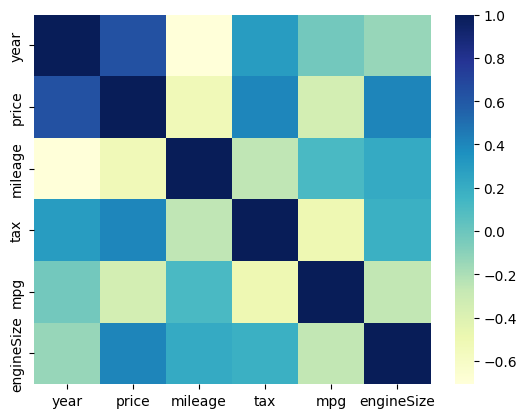

In [47]:
import seaborn as sns

sns.heatmap(data_corr, cmap = 'YlGnBu')

In [48]:
data_cleaned = data_cleaned.drop('mpg', axis=1)
data_cleaned.head()

,year,price,mileage,tax,engineSize
0,2017,12000,15944,113.312747,1.0
1,2018,14000,9083,113.312747,1.0
2,2017,13000,12456,113.312747,1.0
3,2019,17500,10460,113.312747,1.5
4,2019,16500,1482,113.312747,1.0
